# C10 · Who draws the whistle? An item-response model of NBA foul calls

| | |
|---|---|
| **Difficulty** | ★★★★★ |
| **Time** | 5-6 hours |
| **Data** | NBA Last Two Minute reports 2015-2021: 46,861 reviewed plays with the player who (may have) committed a foul, the player who was disadvantaged, and the league's verdict |
| **Skills** | Item-response (Rasch) models · crossed random effects with ~1,600 parameters · identifiability and location invariance · centred vs non-centred geometry · `coords`/`dims` with large index arrays · `nutpie` · group-level predictors · stratified posterior predictive checks · shrinkage · decisions about ranks |

## The brief

Close NBA games are decided at the free-throw line. A team's analytics group is preparing
for the trade deadline and asks two questions:

1. **Which players are best at drawing fouls** late in close games, and which defenders are
   best at **not being whistled**?
2. Both answers must be **separated from the matchup**: a guard who is always defended by
   foul-prone opponents looks good for free, and a centre who only ever guards stars looks
   bad for free.

Their intern ranked players by raw foul rate. The top of the list is a set of players
nobody has heard of, each at 100%. They would like something better - and they want to know
how far to trust any ranking at all.

Since 2015 the league has reviewed every material play in the last two minutes of close
games and published its verdict. Each row of the data is one reviewed play.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task2")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", sigma_theta=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

The models here have about 1,600 parameters and 47,000 observations.
`pm.sample(nuts_sampler="nutpie")` fits each in roughly a minute; budget accordingly.

In [1]:
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats
from scipy.special import expit

from pymc_challenges import Hints, data

RANDOM_SEED = 2021
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

h = Hints("C10")
h.tasks()

**C10 - Who draws the whistle? An item-response model of NBA foul calls**

- `task0` - Define the outcome, look at raw rates (3 hints, 2 check(s))
- `task1` - A colleague's Rasch model and what is wrong with it (3 hints, 1 check(s))
- `task2` - Identification and centred vs non-centred (3 hints, 3 check(s))
- `task3` - Position as a group-level predictor (3 hints, 2 check(s))
- `task4` - Posterior predictive check by position pair (3 hints)
- `task5` - Shrinkage - raw ranking vs posterior ranking (3 hints, 1 check(s))
- `task6` - Rank uncertainty and a specific matchup (3 hints, 2 check(s))

## The data

| column | meaning |
|---|---|
| `committing` | the player who committed the foul - or *would have*, had one been called |
| `disadvantaged` | the player on the receiving end |
| `decision` | the league's review: `CC` correct call, `IC` incorrect call, `CNC` correct no-call, `INC` incorrect no-call |
| `committing_position`, `disadvantaged_position` | G(uard), F(orward), C(entre) and hybrids such as `G-F` |

In [2]:
data.describe("nba_fouls")
fouls = data.load("nba_fouls")
fouls.head()

nba_fouls: Foul calls / non-calls in close games, with committing and disadvantaged player.
  source: NBA Last Two Minute reports 2015-2021, via pymc-examples.
  url:    https://raw.githubusercontent.com/pymc-devs/pymc-examples/main/examples/data/item_response_nba.csv


,committing,disadvantaged,decision,committing_position,disadvantaged_position
play_id,,,,,
1,Avery Bradley,Stephen Curry,CNC,G,G
3,Isaiah Thomas,Andre Iguodala,CNC,G,G-F
4,Jae Crowder,Harrison Barnes,INC,F,F
6,Draymond Green,Isaiah Thomas,CC,F,G
7,Avery Bradley,Stephen Curry,CC,G,G


In [3]:
fouls.decision.value_counts()

decision
CNC    33401
CC     10498
INC     2540
IC       422
Name: count, dtype: int64

## Task 0 · Define the outcome, then look at raw rates

**Deliver**
1. A binary outcome built from `decision`, with a justification: the four codes allow more
   than one defensible definition - which one answers the team's question?
2. The intern's table: the ten players with the highest raw rate of drawing fouls, with the
   number of plays each rate is based on.
3. A plot of raw foul-drawing rate against number of plays for every player, and one
   sentence on why ranking by raw rate is a bad idea.

In [4]:
fouls["foul_called"] = fouls.decision.isin(["CC", "IC"]).astype(int)
y = fouls.foul_called.values
print(f"a foul was called on {y.mean():.3f} of reviewed plays")
print(f"a foul *occurred* (CC or INC) on {fouls.decision.isin(['CC', 'INC']).mean():.3f}")

drawn = fouls.groupby("disadvantaged").foul_called.agg(plays="size", raw_rate="mean")
drawn.sort_values(["raw_rate", "plays"], ascending=False).head(10)

a foul was called on 0.233 of reviewed plays
a foul *occurred* (CC or INC) on 0.278


,plays,raw_rate
disadvantaged,,
Bryce Cotton,2,1.0
DeAndre Liggins,2,1.0
Jarrod Uthoff,2,1.0
Jason Richardson,2,1.0
Lou Amundson,2,1.0
Willie Reed,2,1.0
Brendan Haywood,1,1.0
Carlos Boozer,1,1.0
Dahntay Jones,1,1.0


count    770.0
mean      60.9
std       93.1
min        1.0
25%        5.0
50%       20.0
75%       80.5
max      616.0

players with <= 5 plays as the disadvantaged player: 214 of 770
players with a raw rate of exactly 0 or 1: 156


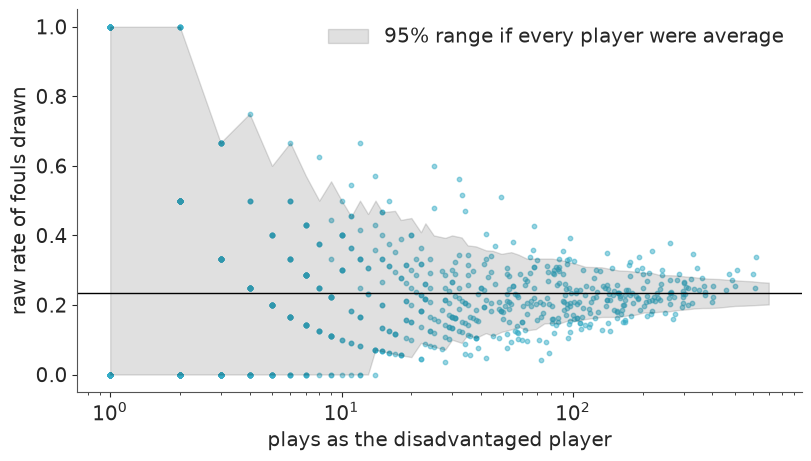

In [5]:
print(drawn.plays.describe().round(1).to_string())
print(f"\nplayers with <= 5 plays as the disadvantaged player: {(drawn.plays <= 5).sum()} of {len(drawn)}")
print(f"players with a raw rate of exactly 0 or 1: {drawn.raw_rate.isin([0, 1]).sum()}")

n_grid = np.unique(np.round(np.geomspace(1, 700, 80))).astype(int)
lo, hi = stats.binom.interval(0.95, n_grid, y.mean())
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(drawn.plays, drawn.raw_rate, s=10, alpha=0.5)
ax.fill_between(n_grid, lo / n_grid, hi / n_grid, color="k", alpha=0.12, label="95% range if every player were average")
ax.axhline(y.mean(), color="k", lw=1)
ax.set(xscale="log", xlabel="plays as the disadvantaged player", ylabel="raw rate of fouls drawn")
ax.legend();

In [6]:
assert h.check("task0", call_rate=y.mean(), players_with_5_or_fewer=(drawn.plays <= 5).sum())

- PASS `call_rate` = 0.233 is consistent with the reference solution.
- PASS `players_with_5_or_fewer` = 214 is consistent with the reference solution.

**Outcome.** The team wants free throws, and free throws come from the whistle, not from
what the review later decided should have happened. So `foul_called = decision in {CC, IC}`
(23% of plays). The alternative, *a foul occurred* (`CC` or `INC`, 28%), measures contact
rather than calls; it would be the right outcome for a question about referee accuracy.
With our definition a player's parameter includes any benefit of the doubt he gets from
referees - for this stakeholder that is a feature.

**Raw rates.** The top ten are all at 100% on one or two plays. The funnel plot shows why:
the spread of raw rates is mostly binomial noise, and it is widest exactly where players
have the fewest plays. A quarter of players have five plays or fewer, and more than a
hundred have a rate of exactly 0 or 1. Ranking by raw rate ranks by *sample size*. It also
ignores the opponent entirely.

## Task 1 · A colleague's Rasch model

Item-response theory was built for exams: the probability that student $i$ answers
question $j$ correctly depends on the student's ability minus the question's difficulty.
Here the "student" is the disadvantaged player and the "question" is the committing player:

$$\text{logit}\,P(\text{foul called}) = \mu + \theta_{\text{disadvantaged}} - b_{\text{committing}}$$

A colleague proposes the natural hierarchical version, "with weakly-informative priors":

$$\theta_i \sim \text{Normal}(\mu_\theta, \sigma_\theta), \quad b_j \sim \text{Normal}(\mu_b, \sigma_b), \quad
\mu \sim \text{Normal}(0, 1.5), \quad \mu_\theta, \mu_b \sim \text{Normal}(0, 5), \quad \sigma_\theta, \sigma_b \sim \text{HalfNormal}(1)$$

**Deliver**
1. This model, fitted to **all** plays, with named dimensions for the two sets of players.
2. Diagnostics for the five top-level parameters. Something is badly wrong. Show with a
   plot *which direction* in parameter space the sampler cannot resolve.
3. Find a function of $\mu, \mu_\theta, \mu_b$ that **is** well determined - report its
   posterior mean and `r_hat` - and explain in two sentences what the data can and cannot
   tell you in this model.

### Solution

`pd.factorize` turns the two name columns into integer index arrays plus the matching
labels for `coords`. A player who appears in both roles gets two unrelated parameters, one
on each dimension.

In [7]:
d_idx, d_names = pd.factorize(fouls.disadvantaged, sort=True)
c_idx, c_names = pd.factorize(fouls.committing, sort=True)
coords = {"disadvantaged": d_names, "committing": c_names}
print(f"{len(d_names)} disadvantaged players, {len(c_names)} committing players, {len(y):,} plays")

with pm.Model(coords=coords) as colleague_model:
    mu = pm.Normal("mu", 0, 1.5)
    mu_theta = pm.Normal("mu_theta", 0, 5)
    mu_b = pm.Normal("mu_b", 0, 5)
    sigma_theta = pm.HalfNormal("sigma_theta", 1)
    sigma_b = pm.HalfNormal("sigma_b", 1)
    theta = pm.Normal("theta", mu_theta, sigma_theta, dims="disadvantaged")
    b = pm.Normal("b", mu_b, sigma_b, dims="committing")
    pm.Bernoulli("foul_called", logit_p=mu + theta[d_idx] - b[c_idx], observed=y)
    colleague_idata = pm.sample(nuts_sampler="nutpie", random_seed=RANDOM_SEED)

TOP = ["mu", "mu_theta", "mu_b", "sigma_theta", "sigma_b"]
az.summary(colleague_idata, var_names=TOP, round_to=2)

NUTS[nutpie]: [mu, mu_theta, mu_b, sigma_theta, sigma_b, theta, b]


770 disadvantaged players, 789 committing players, 46,861 plays


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,-0.36,0.70,-1.53,0.57,4.66,6.42,2.89,0.34,0.15
mu_theta,-0.81,0.55,-1.84,-0.16,4.67,6.90,2.73,0.27,0.14
mu_b,-0.02,0.39,-0.82,0.48,4.76,7.23,2.62,0.18,0.10
sigma_theta,0.30,0.02,0.27,0.33,292.44,400.38,1.00,0.00,0.00
sigma_b,0.41,0.02,0.38,0.45,459.37,783.45,1.00,0.00,0.00


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu + mu_theta - mu_b,-1.145,0.028,-1.189,-1.101,3030.713,2983.923,1.001,0.001,0.0


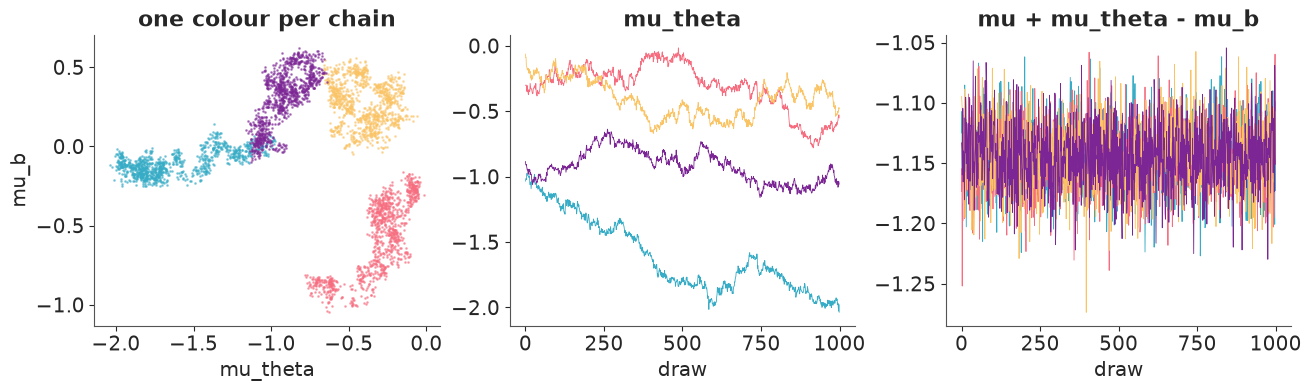

In [8]:
post = colleague_idata.posterior
combo = (post["mu"] + post["mu_theta"] - post["mu_b"]).rename("mu + mu_theta - mu_b")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for chain in post.chain.values:
    axes[0].plot(post["mu_theta"].sel(chain=chain), post["mu_b"].sel(chain=chain), ".", ms=2, alpha=0.5)
    axes[1].plot(post["mu_theta"].sel(chain=chain), lw=0.6)
    axes[2].plot(combo.sel(chain=chain), lw=0.6)
axes[0].set(xlabel="mu_theta", ylabel="mu_b", title="one colour per chain")
axes[1].set(xlabel="draw", title="mu_theta")
axes[2].set(xlabel="draw", title="mu + mu_theta - mu_b")

az.summary(combo.to_dataset(), round_to=3)

In [9]:
assert h.check("task1", identified_combination=combo.mean())

- PASS `identified_combination` = -1.145 is consistent with the reference solution.

The three location parameters have `r_hat` between 2.6 and 2.9 and an effective sample size
of about 5: the four chains sit in four different places and each drifts slowly (middle
panel). Yet the two scales are fine, and the combination $\mu + \mu_\theta - \mu_b$ is
estimated to ±0.03 with `r_hat` 1.00 and an ESS in the thousands.

The likelihood sees the locations only through that combination. Add a constant to every
$\theta$ and subtract it from $\mu$, and no probability changes. In the two remaining
directions the only information is the prior, so the posterior is a ridge as long as the
priors are wide (sd 1.5 to 5) and as narrow as the data are informative (sd 0.03). NUTS
with a diagonal mass matrix crosses such a ridge by slow diffusion; more draws or a higher
`target_accept` would not help. What the data *can* tell us is the log-odds of a call for an
average player against an average opponent (−1.14, about 24%) and how players differ from
one another. What they cannot tell us is how to split that level between "players draw
fouls" and "defenders commit them" - that is a convention, and we have to choose one.

## Task 2 · Identify it, then worry about geometry

**Deliver**
1. An identified version of the model, with a justification of the constraint you chose
   (there is more than one), and a prior predictive check on the probability scale.
2. Fits of **both** a centred and a non-centred parameterisation of the player effects.
   Compare them on divergences and on the effective sample size of $\mu$, $\sigma_\theta$
   and $\sigma_b$, and choose one.
3. An explanation of the difference in terms of the data: which players favour which
   parameterisation, and how many of each are there? Show the relevant posterior geometry
   for one player of each kind.

### Solution

The likelihood only sees $\mu + \theta_i - b_j$. Add a constant to every $\theta$ and
subtract it from $\mu$ and nothing changes: there are three location parameters and the
data determine one. Two ways out:

- **soft**: fix the population means at zero, $\theta_i \sim \text{Normal}(0, \sigma_\theta)$.
  $\mu$ is then the log-odds for an average player against an average opponent.
- **hard**: `pm.ZeroSumNormal`, which forces the effects to sum to exactly zero.

Either works; we take the soft one here (it generalises directly to the position model of
Task 3) and use `ZeroSumNormal` there for the position effects: the average of only seven
position means is far less certain than the average of 770 players, so a soft constraint
would leave $\mu$ poorly determined.

Priors: calls happen on roughly a quarter of plays, so $\mu \sim \text{Normal}(-1, 1)$.
$\sigma \sim \text{HalfNormal}(0.5)$ says that a player one sd above average multiplies the
odds of a call by $e^{\sigma}$: typically less than 1.6, rarely more than 2.7. The prior
predictive check shows what that means for a random matchup.

In [10]:
def rasch(centred):
    with pm.Model(coords=coords) as model:
        mu = pm.Normal("mu", -1, 1)
        sigma_theta = pm.HalfNormal("sigma_theta", 0.5)
        sigma_b = pm.HalfNormal("sigma_b", 0.5)
        if centred:
            theta = pm.Normal("theta", 0, sigma_theta, dims="disadvantaged")
            b = pm.Normal("b", 0, sigma_b, dims="committing")
        else:
            z_theta = pm.Normal("z_theta", 0, 1, dims="disadvantaged")
            z_b = pm.Normal("z_b", 0, 1, dims="committing")
            theta = pm.Deterministic("theta", sigma_theta * z_theta, dims="disadvantaged")
            b = pm.Deterministic("b", sigma_b * z_b, dims="committing")
        pm.Bernoulli("foul_called", logit_p=mu + theta[d_idx] - b[c_idx], observed=y)
    return model


with rasch(centred=False):
    rasch_prior = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)

prior = rasch_prior.prior
p_matchup = expit(prior["mu"] + prior["theta"].isel(disadvantaged=0) - prior["b"].isel(committing=0)).values.ravel()
print("prior quantiles of P(foul called) for a random matchup (3%, 50%, 97%):",
      np.quantile(p_matchup, [0.03, 0.5, 0.97]).round(2))

Sampling: [foul_called, mu, sigma_b, sigma_theta, z_b, z_theta]


prior quantiles of P(foul called) for a random matchup (3%, 50%, 97%): [0.03 0.26 0.78]


In [11]:
fits, rows = {}, []
for name, centred in [("centred", True), ("non-centred", False)]:
    start = time.perf_counter()
    with rasch(centred):
        fits[name] = pm.sample(nuts_sampler="nutpie", random_seed=RANDOM_SEED)
    seconds = time.perf_counter() - start
    top = az.summary(fits[name], var_names=["mu", "sigma_theta", "sigma_b"])
    players = az.summary(fits[name], var_names=["theta", "b"])
    rows.append(
        {
            "parameterisation": name,
            "divergences": int(fits[name].sample_stats["diverging"].sum()),
            "ESS mu": top.loc["mu", "ess_bulk"],
            "ESS sigma_theta": top.loc["sigma_theta", "ess_bulk"],
            "ESS sigma_b": top.loc["sigma_b", "ess_bulk"],
            "min ESS players": players.ess_bulk.min(),
            "max r_hat": max(top.r_hat.max(), players.r_hat.max()),
            "wall time (s)": round(seconds),
        }
    )

pd.DataFrame(rows).set_index("parameterisation")

NUTS[nutpie]: [mu, sigma_theta, sigma_b, theta, b]


NUTS[nutpie]: [mu, sigma_theta, sigma_b, z_theta, z_b]


,divergences,ESS mu,ESS sigma_theta,ESS sigma_b,min ESS players,max r_hat,wall time (s)
parameterisation,,,,,,,
centred,0,707.604829,278.485787,481.905075,2334.823549,1.016132,48
non-centred,0,944.829610,981.243277,905.593338,4516.894984,1.006093,46


In [12]:
rasch_idata = fits["non-centred"]
az.summary(rasch_idata, var_names=["mu", "sigma_theta", "sigma_b"], ci_kind="hdi", ci_prob=0.94, round_to=3)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,-1.143,0.028,-1.196,-1.093,944.830,1379.970,1.002,0.001,0.0
sigma_theta,0.296,0.021,0.256,0.336,981.243,1552.816,1.002,0.001,0.0
sigma_b,0.412,0.023,0.368,0.452,905.593,1315.247,1.004,0.001,0.0


James Harden: 616 plays; Brendan Haywood: 1 play


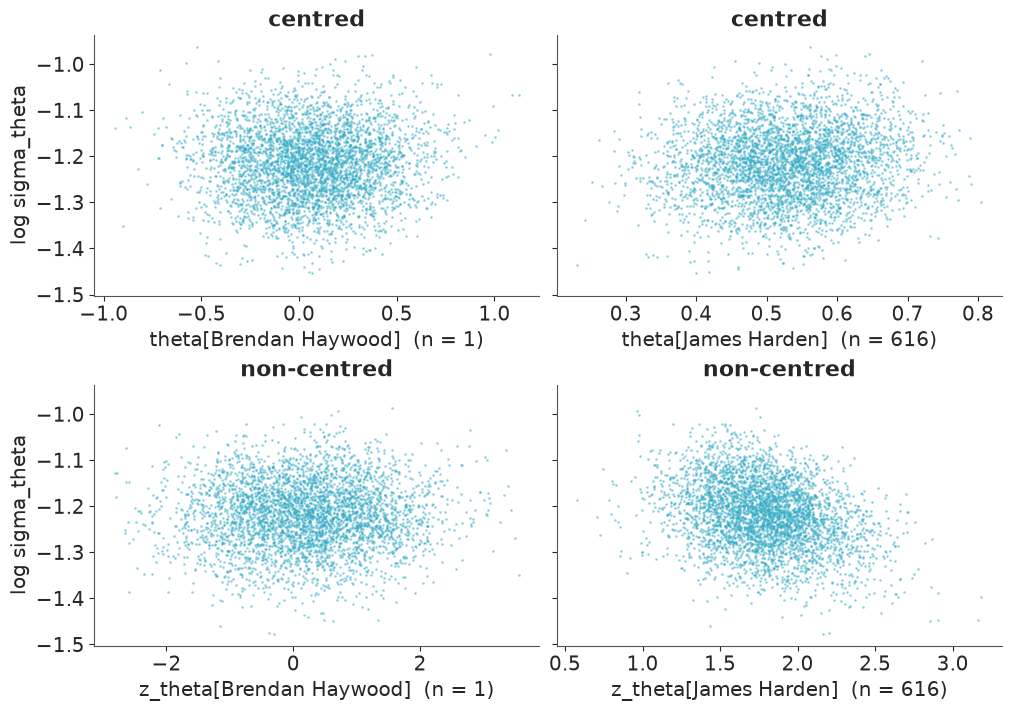

In [13]:
busiest = drawn.plays.idxmax()
one_play = drawn.index[(drawn.plays == 1) & (drawn.raw_rate == 1)][0]
print(f"{busiest}: {drawn.plays[busiest]} plays; {one_play}: {drawn.plays[one_play]} play")

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
for row, (name, var) in enumerate([("centred", "theta"), ("non-centred", "z_theta")]):
    draws = az.extract(fits[name], var_names=["sigma_theta", var])
    for ax, player in zip(axes[row], [one_play, busiest]):
        ax.plot(draws[var].sel(disadvantaged=player), np.log(draws["sigma_theta"]), ".", ms=2, alpha=0.4)
        ax.set(xlabel=f"{var}[{player}]  (n = {drawn.plays[player]})", title=name)
    axes[row, 0].set_ylabel("log sigma_theta")

In [14]:
assert h.check(
    "task2",
    mu=rasch_idata.posterior["mu"].mean(),
    sigma_theta=rasch_idata.posterior["sigma_theta"].mean(),
    sigma_b=rasch_idata.posterior["sigma_b"].mean(),
)

- PASS `mu` = -1.143 is consistent with the reference solution.
- PASS `sigma_theta` = 0.2962 is consistent with the reference solution.
- PASS `sigma_b` = 0.412 is consistent with the reference solution.

Neither parameterisation diverges, and that is worth a moment's thought, because "use
non-centred when groups have little data" is usually sold as a cure for divergences. Here
there are so many players that both scales are pinned down to about ±7%, and the funnel is
correspondingly shallow: in the top-left panel the cloud for a one-play player barely
narrows as $\sigma_\theta$ falls.

The centred model still pays, in efficiency: ESS for $\sigma_\theta$ is about 280 against
980, for $\sigma_b$ 480 against 910, and its worst `r_hat` is 1.016 against 1.006. The
reason is the same funnel seen collectively. Given the current values of 770 $\theta$s,
$\sigma_\theta$ is determined to within roughly $1/\sqrt{2 \cdot 770} \approx 2.5\%$, while
its marginal posterior is ±7% wide - so the sampler can only move $\sigma_\theta$ by
dragging hundreds of weakly-informed $\theta$s along with it. Non-centring removes that
coupling for every player whose posterior is essentially his prior.

Who is that? 214 of the 770 disadvantaged players have five plays or fewer; only about
150 have a hundred or more. For the second kind the likelihood dominates and it is the
*non-centred* coordinates that are correlated with the scale (bottom right: Harden's $z$
must fall when $\sigma_\theta$ rises, because the data fix their product). The many beat
the few, and we keep the non-centred model. With a different mix of players the answer
could flip - measure, do not assume.

## Task 3 · Does position explain it?

Guards handle the ball and attack the rim; centres set screens and protect it. Give both
skills a **group-level predictor**: a player's effect is drawn around the mean of his
position.

**Deliver**
1. The model with position means for both $\theta$ and $b$, identified, with clean
   diagnostics.
2. The posterior of the difference between guards (`G`) and centres (`C`) in foul-drawing
   skill, and the same for $b$. **Do guards draw more fouls than centres?**
3. What happens to $\sigma_\theta$ and $\sigma_b$ compared with Task 2, and what does that
   tell you? Be careful about what a *play* is in this dataset before you interpret the
   position effects on $b$.

In [15]:
POSITIONS = ["G", "G-F", "F-G", "F", "F-C", "C-F", "C"]  # ordered from small to big
d_position = fouls.groupby("disadvantaged").disadvantaged_position.first().reindex(d_names)
c_position = fouls.groupby("committing").committing_position.first().reindex(c_names)
assert fouls.groupby("disadvantaged").disadvantaged_position.nunique().max() == 1  # one position per player
d_pos_idx = pd.Categorical(d_position, categories=POSITIONS).codes
c_pos_idx = pd.Categorical(c_position, categories=POSITIONS).codes

with pm.Model(coords={**coords, "position": POSITIONS}) as position_model:
    mu = pm.Normal("mu", -1, 1)
    sigma_theta = pm.HalfNormal("sigma_theta", 0.5)
    sigma_b = pm.HalfNormal("sigma_b", 0.5)
    pos_theta = pm.ZeroSumNormal("pos_theta", 0.5, dims="position")
    pos_b = pm.ZeroSumNormal("pos_b", 0.5, dims="position")
    z_theta = pm.Normal("z_theta", 0, 1, dims="disadvantaged")
    z_b = pm.Normal("z_b", 0, 1, dims="committing")
    theta = pm.Deterministic("theta", pos_theta[d_pos_idx] + sigma_theta * z_theta, dims="disadvantaged")
    b = pm.Deterministic("b", pos_b[c_pos_idx] + sigma_b * z_b, dims="committing")
    pm.Bernoulli("foul_called", logit_p=mu + theta[d_idx] - b[c_idx], observed=y)
    position_idata = pm.sample(nuts_sampler="nutpie", random_seed=RANDOM_SEED)

players = az.summary(position_idata, var_names=["theta", "b"])
print(f"divergences {int(position_idata.sample_stats['diverging'].sum())}, "
      f"players: min ESS {players.ess_bulk.min():.0f}, max r_hat {players.r_hat.max():.3f}")
az.summary(position_idata, var_names=["mu", "sigma_theta", "sigma_b", "pos_theta", "pos_b"],
           ci_kind="hdi", ci_prob=0.94, round_to=2)

NUTS[nutpie]: [mu, sigma_theta, sigma_b, pos_theta, pos_b, z_theta, z_b]


divergences 0, players: min ESS 3720, max r_hat 1.008


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,-1.27,0.03,-1.33,-1.21,864.62,1285.43,1.00,0.0,0.0
sigma_theta,0.29,0.02,0.25,0.33,989.87,1340.86,1.00,0.0,0.0
sigma_b,0.28,0.02,0.24,0.32,1158.46,1957.52,1.00,0.0,0.0
pos_theta[G],-0.01,0.04,-0.07,0.06,1348.16,1803.03,1.00,0.0,0.0
pos_theta[G-F],-0.15,0.06,-0.26,-0.05,1212.58,1912.31,1.00,0.0,0.0
pos_theta[F-G],-0.15,0.08,-0.30,-0.00,1563.97,2044.69,1.00,0.0,0.0
pos_theta[F],-0.05,0.04,-0.12,0.03,1266.78,1913.00,1.01,0.0,0.0
pos_theta[F-C],0.02,0.07,-0.11,0.15,1473.88,2050.75,1.00,0.0,0.0
pos_theta[C-F],0.17,0.07,0.03,0.32,1525.17,1985.43,1.00,0.0,0.0
pos_theta[C],0.16,0.06,0.04,0.27,1348.02,2046.99,1.00,0.0,0.0


guard - centre, theta: -0.17, 94% HDI [-0.31 -0.03], P(guards higher) = 0.006
guard - centre, b: -0.81, 94% HDI [-0.94 -0.69], P(guards higher) = 0.000

raw call rate by position of the disadvantaged player:
disadvantaged_position
G      0.243
G-F    0.210
F-G    0.200
F      0.226
F-C    0.231
C-F    0.241
C      0.239


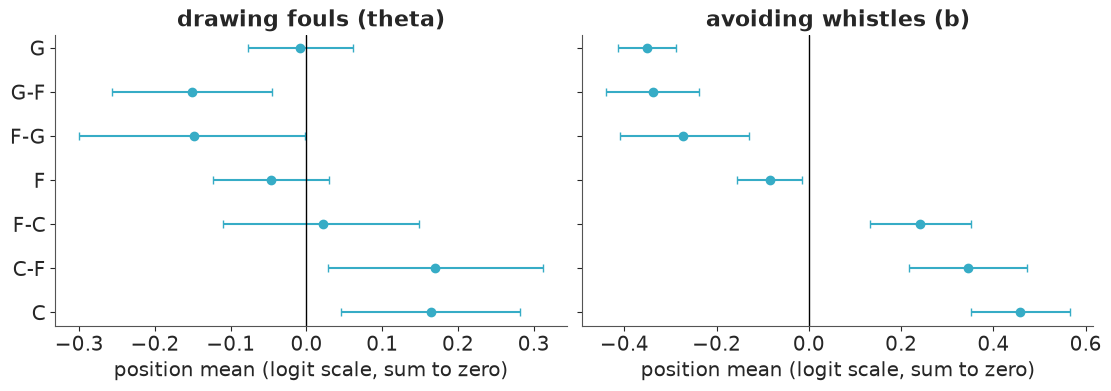

In [16]:
ppost = position_idata.posterior
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, var, title in [(axes[0], "pos_theta", "drawing fouls (theta)"), (axes[1], "pos_b", "avoiding whistles (b)")]:
    draws = ppost[var].stack(sample=("chain", "draw")).values  # (position, sample)
    lo, hi = np.quantile(draws, [0.03, 0.97], axis=1)
    ax.errorbar(draws.mean(1), POSITIONS, xerr=[draws.mean(1) - lo, hi - draws.mean(1)], fmt="o", capsize=3)
    ax.axvline(0, color="k", lw=1)
    ax.set(title=title, xlabel="position mean (logit scale, sum to zero)")
axes[0].invert_yaxis()

gc_theta = ppost["pos_theta"].sel(position="G") - ppost["pos_theta"].sel(position="C")
gc_b = ppost["pos_b"].sel(position="G") - ppost["pos_b"].sel(position="C")
for label, d in [("theta", gc_theta), ("b", gc_b)]:
    print(f"guard - centre, {label}: {float(d.mean()):+.2f}, 94% HDI {az.hdi(d, prob=0.94).values.round(2)}, "
          f"P(guards higher) = {float((d > 0).mean()):.3f}")

print("\nraw call rate by position of the disadvantaged player:")
print(fouls.groupby("disadvantaged_position").foul_called.mean().reindex(POSITIONS).round(3).to_string())

In [17]:
assert h.check("task3", guard_minus_centre_theta=gc_theta.mean(), sigma_b=ppost["sigma_b"].mean())

- PASS `guard_minus_centre_theta` = -0.1719 is consistent with the reference solution.
- PASS `sigma_b` = 0.2812 is consistent with the reference solution.

**Do guards draw more fouls than centres? Per reviewed play, no.** The raw rates are nearly
equal (24.3% for guards, 23.9% for centres), and once the opponent is accounted for centres
and centre-forwards are *higher* than guards by 0.17 on the logit scale (94% HDI −0.31 to
−0.03 for guard minus centre; the probability that guards are higher is under 1%). The
wings (`G-F`, `F-G`) are lowest. The adjustment changes the picture because guards are
most often defended by other guards, the most whistle-prone defenders in the league, so
their raw rate is flattered by their opponents - exactly the matchup effect the team asked
us to remove.

The $b$ side is far more structured: from guards to centres $b$ rises by 0.8. Position
absorbs about half of the between-player variance in $b$ ($\sigma_b$ falls from 0.41 to
0.28), and almost none in $\theta$ (0.30 to 0.29).

**Caveat.** A "play" here is an incident the league chose to review, not a possession or a
minute. Big men are involved in screens, box-outs and rim contests on almost every trip,
many of which are reviewed and ruled clean, so a centre's large $b$ plausibly says more
about *which incidents get listed* than about his discipline. Read $b$ as "whistles per
reviewed incident", and compare defenders **within** a position - which is what the
hierarchy now does for us: each player is shrunk towards players like him.

## Task 4 · Check it where it could fail

The model is additive on the logit scale: a guard's skill is the same whether a guard or a
centre is defending him. That is a strong claim with 49 position pairings to test it on.

**Deliver** a posterior predictive check of the foul-call rate **for every pair of
(disadvantaged position, committing position)**, for the models of Task 2 and Task 3, with
a verdict: is either model adequate for the team's purpose? Where, if anywhere, does
additivity fail?

players only: outside the interval -> C vs C (n=821, obs 0.212, pred 0.178), G vs C (n=2526, obs 0.130, pred 0.171), G vs C-F (n=1374, obs 0.146, pred 0.176), G vs F-C (n=1499, obs 0.173, pred 0.201), G vs G (n=7943, obs 0.296, pred 0.277), G vs G-F (n=1804, obs 0.298, pred 0.272), G-F vs C (n=562, obs 0.121, pred 0.153), G-F vs C-F (n=330, obs 0.103, pred 0.160)
players + position: outside the interval -> C vs C (n=821, obs 0.212, pred 0.171), F-C vs C (n=370, obs 0.197, pred 0.157), G vs C (n=2526, obs 0.130, pred 0.155)


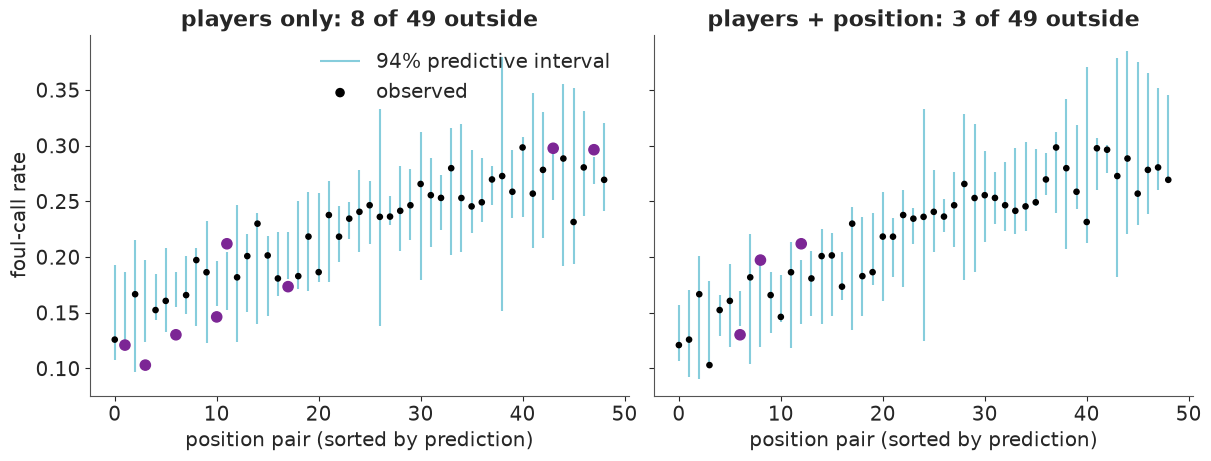

In [18]:
pair_labels = fouls.disadvantaged_position + " vs " + fouls.committing_position
pair_idx, pair_names = pd.factorize(pair_labels, sort=True)
pair_n = np.bincount(pair_idx)
pair_obs = np.bincount(pair_idx, weights=y) / pair_n


def replicated_pair_rates(idata, n_draws=200):
    """Simulate whole replicated datasets and return the call rate per position pair: (pairs, draws)."""
    draws = az.extract(idata, var_names=["mu", "theta", "b"], num_samples=n_draws, random_seed=RANDOM_SEED)
    theta = draws["theta"].transpose("disadvantaged", "sample").values
    b = draws["b"].transpose("committing", "sample").values
    p = expit(draws["mu"].values[None, :] + theta[d_idx] - b[c_idx])  # (plays, draws)
    y_rep = rng.random(p.shape) < p
    return np.stack([np.bincount(pair_idx, weights=y_rep[:, k]) for k in range(n_draws)], axis=1) / pair_n[:, None]


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (label, idata) in zip(axes, [("players only", rasch_idata), ("players + position", position_idata)]):
    rep = replicated_pair_rates(idata)
    lo, hi = np.quantile(rep, [0.03, 0.97], axis=1)
    outside = (pair_obs < lo) | (pair_obs > hi)
    order = np.argsort(rep.mean(1))
    xs = np.arange(len(order))
    ax.vlines(xs, lo[order], hi[order], color="C0", alpha=0.6, label="94% predictive interval")
    ax.scatter(xs, pair_obs[order], s=14 + 40 * outside[order], c=np.where(outside[order], "C3", "k"), zorder=3,
               label="observed")
    ax.set(title=f"{label}: {outside.sum()} of {len(pair_names)} outside", xlabel="position pair (sorted by prediction)")
    print(f"{label}: outside the interval -> "
          + ", ".join(f"{pair_names[i]} (n={pair_n[i]}, obs {pair_obs[i]:.3f}, pred {rep[i].mean():.3f})"
                      for i in np.where(outside)[0]))
axes[0].set_ylabel("foul-call rate")
axes[0].legend();

**Players only.** Eight of 49 pairings fall outside their 94% interval, where chance would
give about three, and the misses have a pattern: the model over-predicts calls when a guard
or wing is matched with a big (`G vs C`: 13.0% observed, 17.1% predicted) and
under-predicts `G vs G`. Player effects alone cannot carry position, because the many
low-data players are shrunk to the league mean rather than to the mean of their position.

**Players + position.** Three misses, which is what chance would give - but they are not
random. All three have a **centre as the committing player**: `C vs C` (21.2% observed,
17.1% predicted), `F-C vs C` (19.7% vs 15.7%) and `G vs C` (13.0% vs 15.5%). Centres are
whistled more than the additive model says when the opponent is another big, and less
when he is a guard. That is a genuine interaction: the skills are not purely additive.

For ranking players the position model is adequate: the discrepancies are 2 to 4
percentage points in 3 cells. For predicting a **specific guard-against-centre matchup**
it is known to run a couple of points high, which we will need to remember in Task 6.

## Task 5 · What shrinkage buys you

**Deliver**
1. For every player, the model's estimate of his foul-drawing rate **against an average
   defender**, plotted against his raw rate, with the number of plays visible in the plot.
2. The top ten by raw rate next to the top ten by posterior mean. How many plays does the
   least-observed player in each list have?
3. Two sentences for the intern on what the model did to the 100% players, and why that is
   not "throwing data away".

28 players with a raw rate of 100% (at most 2 plays): model rates 0.207 to 0.266; league average 0.219


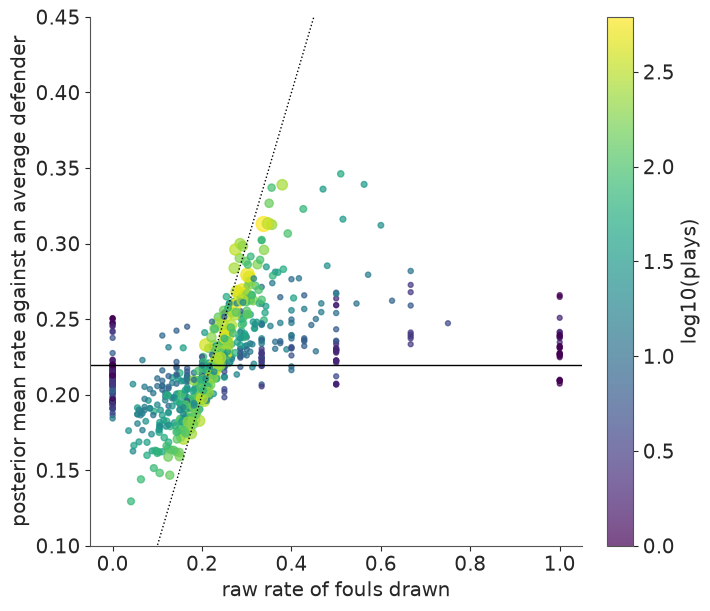

In [19]:
theta_draws = az.extract(position_idata, var_names="theta").transpose("sample", "disadvantaged").values
mu_draws = az.extract(position_idata, var_names="mu").values

skill = drawn.copy()
skill["position"] = d_position.values
skill["theta"] = theta_draws.mean(0)
skill["model_rate"] = expit(mu_draws[:, None] + theta_draws).mean(0)  # against b = 0

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(skill.raw_rate, skill.model_rate, c=np.log10(skill.plays), s=12 + skill.plays / 6, alpha=0.7, cmap="viridis")
ax.plot([0, 1], [0, 1], color="k", lw=1, ls=":")
ax.axhline(expit(mu_draws).mean(), color="k", lw=1)
ax.set(xlabel="raw rate of fouls drawn", ylabel="posterior mean rate against an average defender", ylim=(0.1, 0.45))
fig.colorbar(sc, label="log10(plays)")

perfect = skill[skill.raw_rate == 1]
print(f"{len(perfect)} players with a raw rate of 100% (at most {perfect.plays.max()} plays): "
      f"model rates {perfect.model_rate.min():.3f} to {perfect.model_rate.max():.3f}; "
      f"league average {expit(mu_draws).mean():.3f}")

In [20]:
raw_top = skill.sort_values(["raw_rate", "plays"], ascending=False).head(10)
post_top = skill.sort_values("theta", ascending=False).head(10)
side_by_side = pd.DataFrame(
    {
        "raw top 10": raw_top.index, "plays ": raw_top.plays.values, "raw ": raw_top.raw_rate.values.round(2),
        "posterior top 10": post_top.index, "plays": post_top.plays.values, "raw": post_top.raw_rate.values.round(2),
        "model rate": post_top.model_rate.values.round(3),
    },
    index=pd.RangeIndex(1, 11, name="rank"),
)
side_by_side

,raw top 10,plays,raw,posterior top 10,plays,raw,model rate
rank,,,,,,,
1,Bryce Cotton,2,1.0,Kenneth Faried,49,0.51,0.346
2,DeAndre Liggins,2,1.0,John Wall,261,0.38,0.339
3,Jarrod Uthoff,2,1.0,Mario Chalmers,32,0.56,0.339
4,Jason Richardson,2,1.0,Dwight Howard,90,0.36,0.337
5,Lou Amundson,2,1.0,Gorgui Dieng,34,0.47,0.336
6,Willie Reed,2,1.0,DeAndre Jordan,140,0.35,0.327
7,Brendan Haywood,1,1.0,Monta Ellis,68,0.43,0.323
8,Carlos Boozer,1,1.0,Trevor Booker,33,0.52,0.316
9,Dahntay Jones,1,1.0,Stephen Curry,328,0.35,0.313


In [21]:
assert h.check("task5", min_plays_in_posterior_top10=post_top.plays.min())

- PASS `min_plays_in_posterior_top10` = 32 is consistent with the reference solution.

The raw top ten are ten men with one or two plays each. The posterior top ten have between
32 and 616 plays and include John Wall, Stephen Curry and James Harden - names a scout would
recognise. In the scatter plot, players with hundreds of plays (yellow) stay close to the
diagonal: the data speak for themselves. Players with a handful of plays (purple) are
pulled almost all the way to the average for their position, whatever their raw rate.

**For the intern.** The model did not discard the 100% players' data; it weighed them. One
whistle in one play is what you would expect to see about a quarter of the time from an
*average* player, so it is almost no evidence of skill, and the posterior moves those
28 players to model rates between 21% and 27%, against a league average of 22%. A rate of
38% sustained over 261 plays, as for Wall, is strong evidence, and the model believes most
of it (34% against an average defender).

## Task 6 · Rankings the front office can use

A posterior mean is still a point estimate, and the front office will read a ranked list as
if rank 3 were better than rank 7.

**Deliver**
1. For the leading candidates: the posterior probability of being among the **ten best
   foul-drawers in the league**, and a 94% interval for each player's **rank**. Is anybody
   in the top ten with probability above one half?
2. The same treatment, briefly, for defenders who avoid the whistle.
3. A specific matchup: **James Harden has the ball and Rudy Gobert is defending.** The
   posterior of P(foul called) with an interval - and the same with an average centre in
   place of Gobert, to show what the defender is worth.
4. Three sentences for the front office on how to use (and not use) the list.

In [22]:
def rank_table(draws, names, plays, top=10):
    """draws: (sample, player), larger is better. Rank 1 = best within each posterior draw."""
    ranks = (-draws).argsort(axis=1).argsort(axis=1) + 1
    table = pd.DataFrame(
        {
            "plays": plays,
            "posterior mean": draws.mean(0),
            f"P(top {top})": (ranks <= top).mean(0),
            "rank lo94": np.quantile(ranks, 0.03, axis=0),
            "rank hi94": np.quantile(ranks, 0.97, axis=0),
        },
        index=names,
    )
    return table.sort_values(f"P(top {top})", ascending=False)


draw_ranks = rank_table(theta_draws, d_names, drawn.plays.reindex(d_names).values)
draw_ranks.head(12).round(3)

,plays,posterior mean,P(top 10),rank lo94,rank hi94
Kenneth Faried,49,0.626,0.436,1.00,167.00
Mario Chalmers,32,0.593,0.394,1.00,228.00
Gorgui Dieng,34,0.579,0.370,1.00,240.00
Dwight Howard,90,0.587,0.348,1.00,155.03
John Wall,261,0.598,0.316,2.00,77.03
Monta Ellis,68,0.522,0.232,2.00,218.00
Trevor Booker,33,0.488,0.227,1.00,304.06
DeAndre Jordan,140,0.541,0.218,2.97,146.03
Matt Barnes,25,0.467,0.216,1.00,368.03
Greg Monroe,42,0.422,0.140,3.00,374.00


In [23]:
# the pessimist's view: whose *worst plausible* rank is best?
draw_ranks.sort_values("rank hi94").head(8).round(3)

,plays,posterior mean,P(top 10),rank lo94,rank hi94
John Wall,261,0.598,0.316,2.00,77.03
James Harden,616,0.481,0.026,11.00,99.00
Stephen Curry,328,0.482,0.060,8.00,131.00
DeAndre Jordan,140,0.541,0.218,2.97,146.03
Dwight Howard,90,0.587,0.348,1.00,155.03
Isaiah Thomas,219,0.477,0.086,6.00,161.00
Kenneth Faried,49,0.626,0.436,1.00,167.00
DeMarcus Cousins,242,0.418,0.040,9.00,204.03


In [24]:
# defenders: rank the *within-position* part of b (see the caveat in Task 3)
b_draws = az.extract(position_idata, var_names="b").transpose("sample", "committing").values
pos_b_draws = az.extract(position_idata, var_names="pos_b").transpose("sample", "position").values
b_within = b_draws - pos_b_draws[:, c_pos_idx]
committed_plays = fouls.groupby("committing").size().reindex(c_names).values
avoid_ranks = rank_table(b_within, c_names, committed_plays)
avoid_ranks.insert(0, "position", c_position.reindex(avoid_ranks.index).values)
avoid_ranks.head(8).round(3)

,position,plays,posterior mean,P(top 10),rank lo94,rank hi94
Alex Caruso,G,43,0.521,0.325,1.0,273.00
Robin Lopez,C,196,0.530,0.306,1.0,216.00
Taj Gibson,F,213,0.518,0.264,2.0,174.00
Shai Gilgeous-Alexander,G-F,87,0.498,0.252,1.0,251.00
Carmelo Anthony,F,149,0.485,0.227,2.0,228.00
Kyrie Irving,G,204,0.507,0.212,2.0,158.00
Kevon Looney,F,62,0.456,0.206,1.0,333.03
Noah Vonleh,F,59,0.427,0.180,2.0,359.00


In [25]:
harden = list(d_names).index("James Harden")
gobert = list(c_names).index("Rudy Gobert")
pos_b_centre = pos_b_draws[:, POSITIONS.index("C")]

p_gobert = expit(mu_draws + theta_draws[:, harden] - b_draws[:, gobert])
p_avg_centre = expit(mu_draws + theta_draws[:, harden] - pos_b_centre)
met = fouls[(fouls.disadvantaged == "James Harden") & (fouls.committing == "Rudy Gobert")]
print(f"they met on {len(met)} reviewed plays, {met.foul_called.sum()} fouls called")
for label, p in [("Harden vs Gobert", p_gobert), ("Harden vs an average centre", p_avg_centre)]:
    print(f"{label:<28} P(foul called) = {p.mean():.3f}, 94% interval {np.quantile(p, [0.03, 0.97]).round(3)}")
print(f"P(Gobert is whistled less than an average centre in this matchup) = {np.mean(p_gobert < p_avg_centre):.2f}")

they met on 4 reviewed plays, 2 fouls called
Harden vs Gobert             P(foul called) = 0.245, 94% interval [0.196 0.3  ]
Harden vs an average centre  P(foul called) = 0.224, 94% interval [0.191 0.259]
P(Gobert is whistled less than an average centre in this matchup) = 0.19


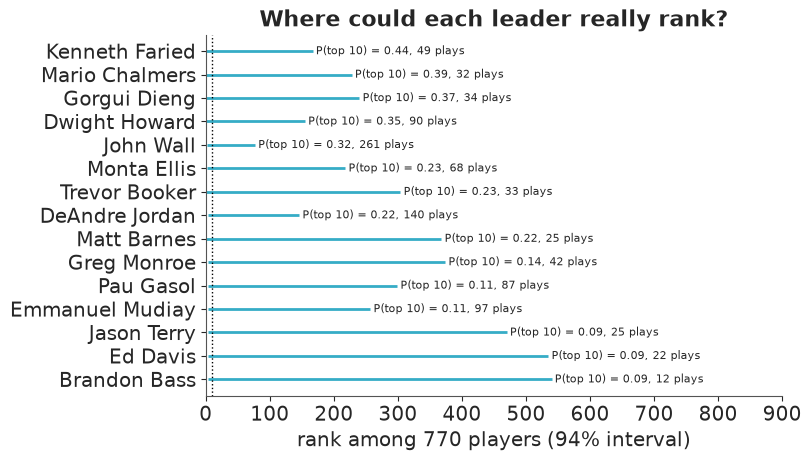

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
leaders = draw_ranks.head(15)[::-1]
ax.hlines(leaders.index, leaders["rank lo94"], leaders["rank hi94"], color="C0", lw=2)
for name, row in leaders.iterrows():
    ax.text(row["rank hi94"] + 5, name, f"P(top 10) = {row['P(top 10)']:.2f}, {int(row.plays)} plays", va="center", fontsize=8)
ax.axvline(10, color="k", ls=":", lw=1)
ax.set(xlabel=f"rank among {len(d_names)} players (94% interval)", xlim=(0, 900), title="Where could each leader really rank?");

In [27]:
assert h.check("task6", max_p_top10=draw_ranks["P(top 10)"].max(), p_harden_vs_gobert=p_gobert.mean())

- PASS `max_p_top10` = 0.4358 is consistent with the reference solution.
- PASS `p_harden_vs_gobert` = 0.2453 is consistent with the reference solution.

**Is anybody in the top ten with probability above one half? No.** The most likely member is
Kenneth Faried at 0.44, on 49 plays; five players are above 0.3. The rank intervals are
enormous - Faried's runs from 1st to 167th, Chalmers' from 1st to 228th. The ordering of
posterior means in Task 5 was a fragile summary of this.

**Which summary you rank by is a decision, not a detail.** $P(\text{top 10})$ rewards
uncertainty as well as skill: Matt Barnes, on 25 plays, gets 0.22 with a rank interval of 1
to 368, while James Harden, on 616 plays, gets 0.03 although he is *certainly* very good
(11th to 99th). The pessimist's table - sorted by worst plausible rank - is the one to use
if the team wants a dependable foul-drawer rather than a lottery ticket: John Wall (2nd to
77th), then Harden and Curry. Wall and Dwight Howard are the only players in the top five of
both lists.

**Defenders** are ranked on the within-position part of $b$, so that guards are compared
with guards. Nobody stands out: the best candidates (Alex Caruso, Robin Lopez, Taj Gibson)
have a probability of about 0.3 of being in the top ten, and even Lopez, on 196 plays,
could plausibly rank anywhere from 1st to 216th of 789. The data separate defenders within a
position much less sharply than the raw rates suggest.

**The matchup.** Harden against Gobert: a foul is called on 24.5% of reviewed plays, 94%
interval 20% to 30%. Against an average centre it would be 22.4%, and the probability that
Gobert is whistled *less* than an average centre is only 0.19 - in these reports he is
probably slightly more whistle-prone than his peers. The four plays on which the two actually
met (two fouls) tell us almost nothing by themselves; the model borrows Harden's 616 plays
and Gobert's 395. Remember Task 4, though: the additive model ran about 2.5 points high for
guards against centres, so shade this estimate down.

**For the front office.** (1) Read the lists as tiers, not ranks: the data cannot
distinguish 3rd from 30th. (2) Pick the summary that matches the decision - $P(\text{top
10})$ for upside, worst plausible rank for reliability - and distrust any candidate with
fewer than about fifty plays. (3) These are skills **per reviewed incident in the last two
minutes of close games**, whistles included, referees' habits included. They say nothing
about how often a player gets into such incidents, which for free throws per game matters
at least as much.

## Going further

- **One player, two skills.** Most players appear in both roles. Give each player a
  bivariate effect $(\theta_i, b_i)$ with an `LKJCholeskyCov` prior. Are good foul-drawers
  also whistle-prone defenders?
- **Matchup interactions.** Task 4 tests additivity only at the position level. Add a
  position-pair interaction (`ZeroSumNormal` over two dims) and compare with LOO. Is it
  worth 49 more parameters?
- **Referee error instead of whistles.** Refit with the outcome "the call was wrong"
  (`IC` or `INC`). Do some players get the benefit of the doubt?
- **Does skill drift?** The file has no dates, but the reports do. Get the season for each
  play from the original L2M data and let $\theta$ follow a random walk across seasons.

In [28]:
h.progress()

**C10**: 0/21 hints used, 11/11 checks passed.